# JB_22 dose-day tinyRNN RNN fit

Minimal tinyRNN RNN training on the JB_22 dose-day session.

This notebook keeps the setup simple:
- use the local tinyRNN `RNNAgent` and `Trainer`
- load the JB_22 dose-day session
- train a small GRU on stimulus/history inputs to predict choice
- prefer Apple `mps` when available, otherwise fall back to CPU


In [1]:
from pathlib import Path
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Make sure torch can import cleanly on macOS.
os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')

repo_root = Path.cwd().resolve()
tinyrnn_root = Path('/Users/hunglo/Documents/GitHub/tinyRNN').resolve()
assert tinyrnn_root.exists(), tinyrnn_root

# Put tinyRNN first on the import path.
for p in [tinyrnn_root, repo_root]:
    ps = str(p)
    if ps not in sys.path:
        sys.path.insert(0, ps)

import path_settings

# Keep tinyRNN outputs inside this repo.
save_root = repo_root / 'tinyRNN_saved_model'
save_root.mkdir(parents=True, exist_ok=True)
path_settings.MODEL_SAVE_PATH = save_root

import torch
device = torch.device('cpu')

from agents import RNNAgent, Trainer

print('repo_root:', repo_root)
print('tinyrnn_root:', tinyrnn_root)
print('save_root:', save_root)
print('torch version:', torch.__version__)
print('using device:', device)

repo_root: /Users/hunglo/Documents/GitHub/RNN_modeling
tinyrnn_root: /Users/hunglo/Documents/GitHub/tinyRNN
save_root: /Users/hunglo/Documents/GitHub/RNN_modeling/tinyRNN_saved_model
torch version: 2.12.1
using device: cpu


mouse: JB_22
session_idx: 4
session_date: 2025-10-31
n_trials: 500
stimulus counts: {'go': 250, 'nogo': 250}
choice counts: {0: 241, 1: 259}
reward unique: [-1.  0.  1.]
input shape: (500, 1, 3)
target shape: (500, 1)


([<matplotlib.axis.YTick at 0x334a83cd0>,
 [Text(0, 0, 'signed stimulus'),
  Text(0, 1, 'prev choice'),
  Text(0, 2, 'prev reward')])

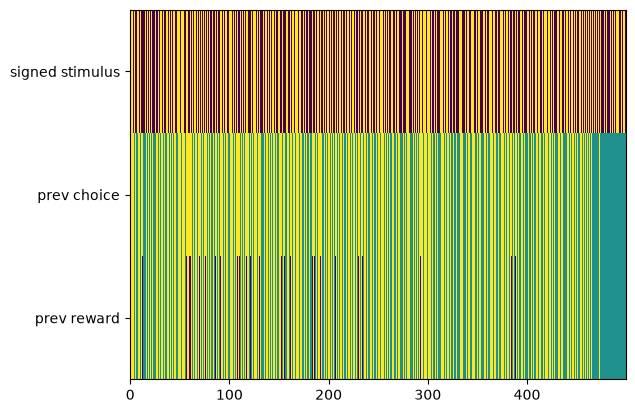

In [36]:
bundle_path = repo_root / 'codex_proecessed_data' / 'mf_preprocessed' / 'JB_22_sessionwise_mf.npz'
bundle = np.load(bundle_path, allow_pickle=True)

session_idx = 4
stimulus = np.asarray(bundle['stimulus_by_session'][session_idx], dtype=np.int64)
choice = np.asarray(bundle['choice_by_session'][session_idx], dtype=np.int64)
reward = np.asarray(bundle['reward_by_session'][session_idx], dtype=np.float64)

n_trials = len(choice)

# Very simple inputs:
# 0: signed stimulus (+1 Go, -1 NoGo)
# 1: previous choice
# 2: previous reward
X = np.zeros((n_trials, 3), dtype=np.float64)
X[:, 0] = stimulus.astype(np.float64)
X[1:, 1] = choice[:-1].astype(np.float64)
X[1:, 2] = reward[:-1].astype(np.float64)

# TinyRNN expects seq_len x batch x feature/target dims.
input_tensor = torch.tensor(X[:, None, :], dtype=torch.float64, device=device)
target_tensor = torch.tensor(choice[:, None], dtype=torch.long, device=device)
mask_tensor = torch.ones((n_trials, 1), dtype=torch.float64, device=device)

data = {
    'train': {'input': input_tensor, 'target': target_tensor, 'mask': mask_tensor},
    'val': {'input': input_tensor, 'target': target_tensor, 'mask': mask_tensor},
    'test': {'input': input_tensor, 'target': target_tensor, 'mask': mask_tensor},
}

print('mouse:', str(bundle['mouse_id']))
print('session_idx:', session_idx)
print('session_date:', str(bundle['session_date'][session_idx]))
print('n_trials:', n_trials)
print('stimulus counts:', {'go': int((stimulus > 0).sum()), 'nogo': int((stimulus < 0).sum())})
print('choice counts:', {0: int((choice == 0).sum()), 1: int((choice == 1).sum())})
print('reward unique:', np.unique(reward))
print('input shape:', tuple(input_tensor.shape))
print('target shape:', tuple(target_tensor.shape))

plt.imshow(X.T,aspect='auto',interpolation='none')
plt.yticks([0,1,2],['signed stimulus','prev choice','prev reward'])

In [37]:
config = {
    'rnn_type': 'GRU',
    'input_dim': 3,
    'hidden_dim': 8,
    'output_dim': 2,
    'output_h0': False,
    'trainable_h0': False,
    'readout_FC': True,
    'one_hot': False,
    'lr': 0.005,
    'weight_decay': 0.0,
    'max_epoch_num': 1000,
    'early_stop_counter': 100,
    'batch_size': 0,
    'save_model_pass': 'minimal',
    'model_path': 'jb22_dose_day_rnn_tinyrnn',
    'seed': 0,
    'device':str(device)
}

rnn = RNNAgent(config)
trainer = Trainer(rnn)

print('model class:', type(trainer.model))
print('num params:', trainer.num_params)
print('device:', next(trainer.model.parameters()).device)
print('config hidden_dim:', config['hidden_dim'])

model class: <class 'agents.network_models.RNNnet'>
num params: 330
device: cpu
config hidden_dim: 8


In [38]:
trainer.train(data=data, verbose_level=1)

train_pass = trainer.best_model_pass['train']
summary = pd.DataFrame({
    'param': ['behav_loss', 'total_trial_num'],
    'value': [train_pass['behav_loss'], train_pass['total_trial_num']],
})
summary

/Users/hunglo/Documents/GitHub/tinyRNN/agents/RNNAgentTrainer.py:137: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(enabled=self.use_amp)
  0%|          | 4/1001 [00:00<01:02, 15.86it/s]

Epoch 0, train loss 0.6781, val loss 0.6781, test loss 0.6781


  1%|          | 12/1001 [00:00<00:58, 16.94it/s]

Epoch 10, train loss 0.6101, val loss 0.6101, test loss 0.6101


  2%|▏         | 24/1001 [00:01<00:58, 16.72it/s]

...

 71%|███████▏  | 714/1001 [00:43<00:16, 17.24it/s]

Epoch 710, train loss 0.1776, val loss 0.1776, test loss 0.1776


 72%|███████▏  | 719/1001 [00:44<00:17, 16.32it/s]


Model jb22_dose_day_rnn_tinyrnn Training done. time cost: 44.07426404953003 best train loss: 0.1129064044510097 best val loss: 0.1129064044510097 best test loss: 0.1129064044510097


,param,value
0,behav_loss,0.112906
1,total_trial_num,500.000000


In [39]:
# print('train behav_loss:', trainer.best_model_pass['train']['behav_loss'])
# print('val behav_loss:', trainer.best_model_pass['val']['behav_loss'])
# print('test behav_loss:', trainer.best_model_pass['test']['behav_loss'])
# print('total_trial_num:', trainer.best_model_pass['train']['total_trial_num'])
# print('model saved under:', save_root / config['model_path'])

# # Quick inspection: predicted lick probability over trials.
# with torch.no_grad():
#     out = trainer.forward(data['train'])['output']
#     probs = torch.softmax(out, dim=-1).detach().cpu().numpy()[:, 0, 1]

# print('first 10 predicted lick probs:', np.round(probs[:10], 3))
# print('first 10 choices:', choice[:10])

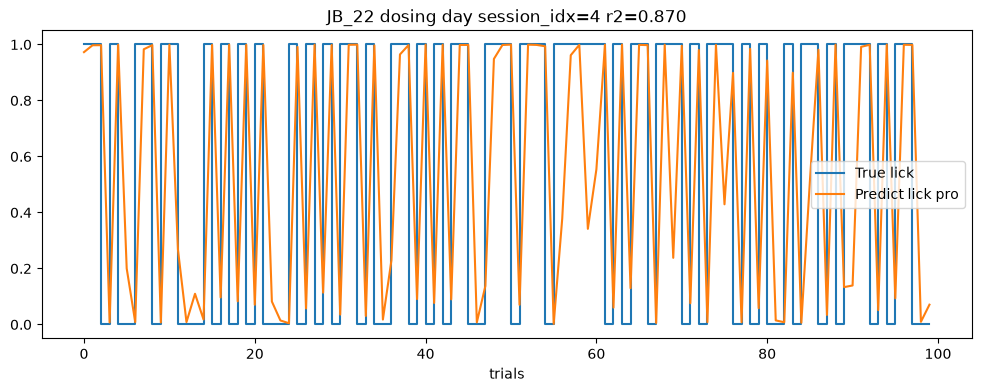

In [58]:
# Quick inspection: predicted lick probability over trials.
with torch.no_grad():
    out = trainer.forward(data['train'])['output']
    probs = torch.softmax(out, dim=-1).detach().cpu().numpy()[:, 0, 1]

## compute r2 
from sklearn.metrics import r2_score
r2 = r2_score(choice,probs)

trials_plot = 100
trials_start = 0
plt.figure(figsize=[12,4])
plt.step(range(trials_start,trials_start+trials_plot),choice[trials_start:trials_start+trials_plot],label='True lick')
plt.plot(range(trials_start,trials_start+trials_plot),probs[trials_start:trials_start+trials_plot],label='Predict lick pro')
# plt.plot(np.where(stimulus[trials_start:trials_start+trials_plot]==1)[0], np.ones(len(np.where(stimulus[trials_start:trials_start+trials_plot]==1)[0]))*1.2,marker='|',ls='none')

plt.xlabel('trials')
plt.title(f"JB_22 dosing day {session_idx=} {r2=:.3f}")
plt.legend()
plt.show()